<a href="https://colab.research.google.com/github/YeicobD/TelecomX/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [65]:
import pandas as pd
import requests
import numpy as np

In [66]:
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

data = requests.get(url).json()

df = pd.DataFrame(data)

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [67]:
df.shape
df.columns

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

#🔧 Transformación

In [68]:
df.columns

Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [70]:
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


### Variables relevantes para analizar la evasión de clientes (Churn)

La variable principal del análisis es **Churn**, ya que indica si el cliente abandonó la empresa.

Además, se identifican grupos de variables que pueden influir en la evasión de clientes:

- Información del cliente (customer)
- Servicios telefónicos (phone)
- Servicios de internet (internet)
- Información de la cuenta y pagos (account)



#Comprobación de incoherencias en los datos

##1. Revisar valores nulos

In [71]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer,0
phone,0
internet,0
account,0


##2. Revisar registros duplicados

In [72]:
df[['customerID', 'Churn']].duplicated().sum()


np.int64(0)

Resultado de la verificación de duplicados:

No se encontraron registros duplicados en las columnas principales del dataset. Esto indica que cada cliente tiene un identificador único y no hay repeticiones en los datos analizados.

##3. Valores de churn:

In [73]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


### Análisis de la variable Churn

Al revisar los valores de la variable Churn se identificaron tres tipos de registros:

- Clientes que permanecen en la empresa (No)
- Clientes que abandonaron la empresa (Yes)
- Registros con valores vacíos

Esto indica que existen inconsistencias en los datos que deberán ser tratadas en la etapa de limpieza de datos.

In [74]:
df['Churn'].unique()

array(['No', 'Yes', ''], dtype=object)

#Manejo de inconsistencias

##1. Convertir valores vacíos en NaN

In [75]:
##Primero transformamos los vacíos en valores nulos

df['Churn'] = df['Churn'].replace('', pd.NA)

##2. Revisar cuántos valores nulos hay ahora

In [76]:
df['Churn'].isna().sum()

np.int64(224)

##3. Eliminar esos registros

In [77]:
df = df.dropna(subset=['Churn'])

##4. Verificar que ya quedó limpio

In [78]:
df['Churn'].unique()

array(['No', 'Yes'], dtype=object)

##5. Verificar nuevamente el conteo

In [79]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


### Manejo de inconsistencias en los datos

Se identificaron valores vacíos en la variable Churn, lo que representaba una inconsistencia en el dataset.

Para solucionar este problema:
1. Se reemplazaron los valores vacíos por valores nulos (NaN).
2. Se eliminaron los registros incompletos.

Después de esta limpieza, la variable Churn quedó con valores consistentes para el análisis.

#Cargo mensual

In [80]:
df['account'].iloc[0]

{'Contract': 'One year',
 'PaperlessBilling': 'Yes',
 'PaymentMethod': 'Mailed check',
 'Charges': {'Monthly': 65.6, 'Total': '593.3'}}

#Columna cuentas diarias

In [81]:
df['Cuentas_Diarias'] = df['account'].apply(lambda x: x['Charges']['Monthly'] / 30)
df[['Cuentas_Diarias']].head()


,Cuentas_Diarias
0,2.186667
1,1.996667
2,2.463333
3,3.266667
4,2.796667


### Creación de la columna Cuentas Diarias

Se creó una nueva variable llamada **Cuentas_Diarias**, calculada a partir del cargo mensual del cliente dividido entre 30 días.

Esta variable permite analizar el comportamiento del gasto de los clientes de manera más detallada.

#Estandarizacion y transformacion de datos

In [82]:
# Convertir Yes/No a 1 y 0
df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})

# Reemplazar valores vacíos por NaN
df.replace('', np.nan, inplace=True)

# Verificar cambios
df['Churn'].unique()

/tmp/ipykernel_491/549025674.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})


array([0, 1])

#📊 Carga y análisis

##1. Análisis descriptivo

In [83]:
df.describe()

,Churn,Cuentas_Diarias
count,7043.000000,7043.000000
mean,0.265370,2.158723
std,0.441561,1.003002
min,0.000000,0.608333
25%,0.000000,1.183333
50%,0.000000,2.345000
75%,1.000000,2.995000
max,1.000000,3.958333


##2. Métricas principales

In [84]:
media = df.mean(numeric_only=True)
mediana = df.median(numeric_only=True)
desviacion = df.std(numeric_only=True)

print("Media:")
print(media)

print("\nMediana:")
print(mediana)

print("\nDesviación estándar:")
print(desviacion)

Media:
Churn              0.265370
Cuentas_Diarias    2.158723
dtype: float64

Mediana:
Churn              0.000
Cuentas_Diarias    2.345
dtype: float64

Desviación estándar:
Churn              0.441561
Cuentas_Diarias    1.003002
dtype: float64


##3. Variable Churn

In [85]:
df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [86]:
descripcion = df.describe()
churn_conteo = df['Churn'].value_counts()

In [87]:
import matplotlib.pyplot as plt

#Distribución de evasión

##1. Cuántos clientes se fueron y cuántos no

In [88]:
churn_counts = df['Churn'].value_counts()
print(churn_counts)

Churn
0    5174
1    1869
Name: count, dtype: int64


##2. Gráfico de distribución

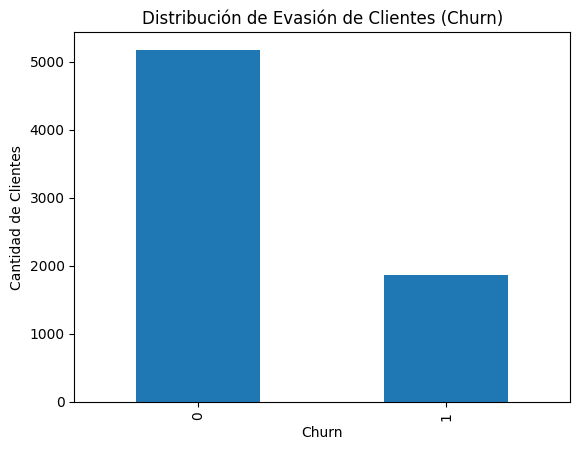

In [89]:
churn_counts.plot(kind='bar')
plt.title('Distribución de Evasión de Clientes (Churn)')
plt.xlabel('Churn')
plt.ylabel('Cantidad de Clientes')
plt.show()

In [90]:
df['Churn'].value_counts(normalize=True) * 100

,proportion
Churn,
0,73.463013
1,26.536987


#Recuento de evasión por variables categóricas

In [91]:
df.select_dtypes(include='object').columns

Index(['customerID', 'customer', 'phone', 'internet', 'account'], dtype='object')

In [92]:
customer = pd.json_normalize(df['customer'])
phone = pd.json_normalize(df['phone'])
internet = pd.json_normalize(df['internet'])
account = pd.json_normalize(df['account'])

df = pd.concat([df, customer, phone, internet, account], axis=1)

df = df.drop(columns=['customer', 'phone', 'internet', 'account'])

In [93]:
df.columns

Index(['customerID', 'Churn', 'Cuentas_Diarias', 'gender', 'SeniorCitizen',
       'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly',
       'Charges.Total'],
      dtype='object')

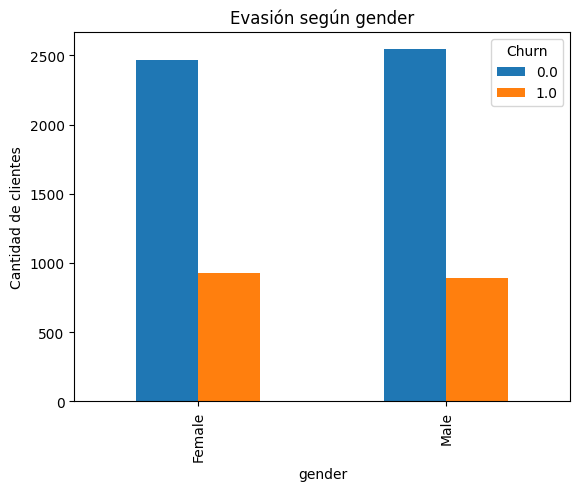

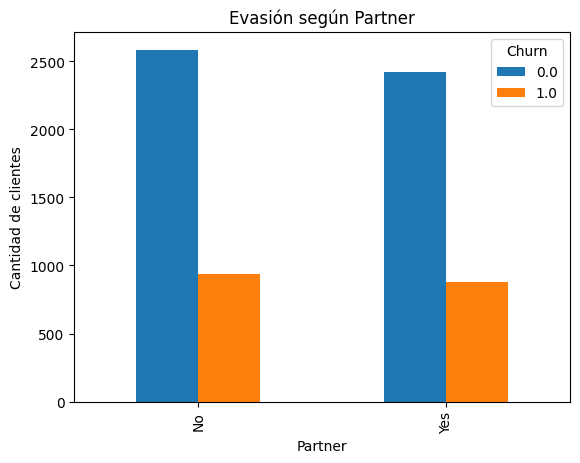

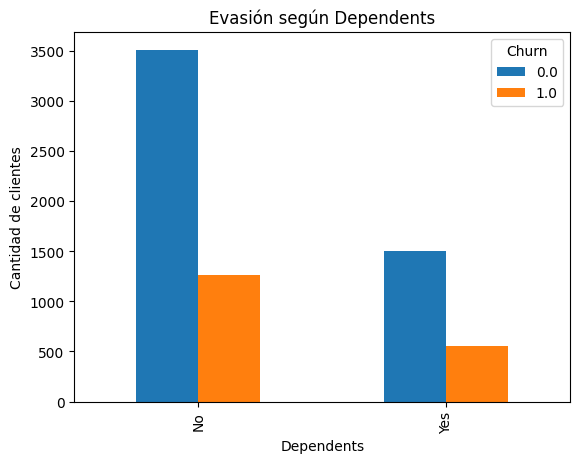

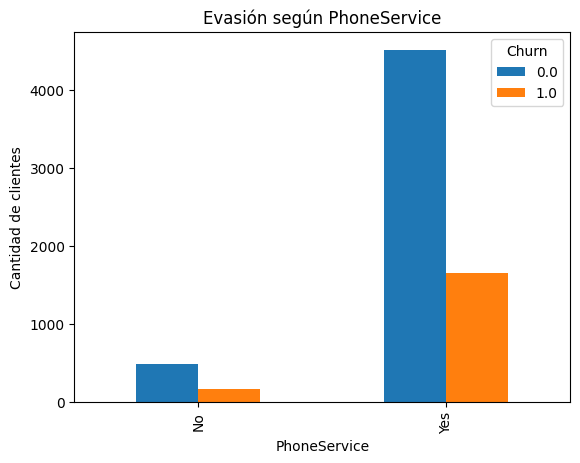

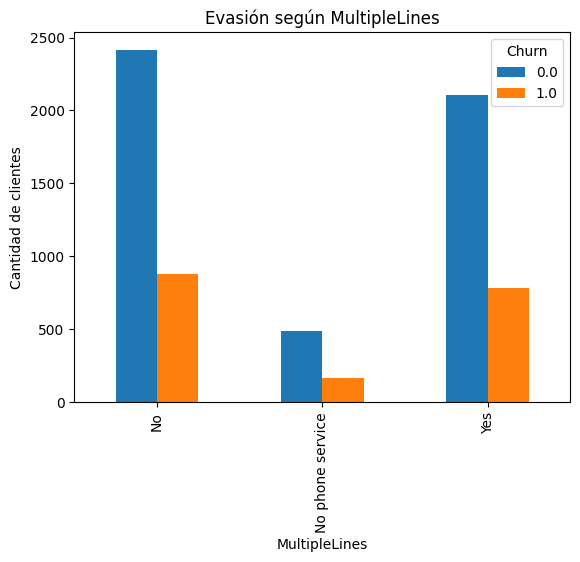

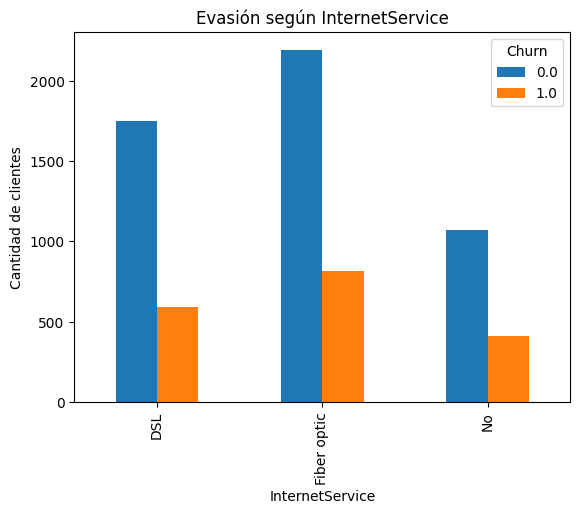

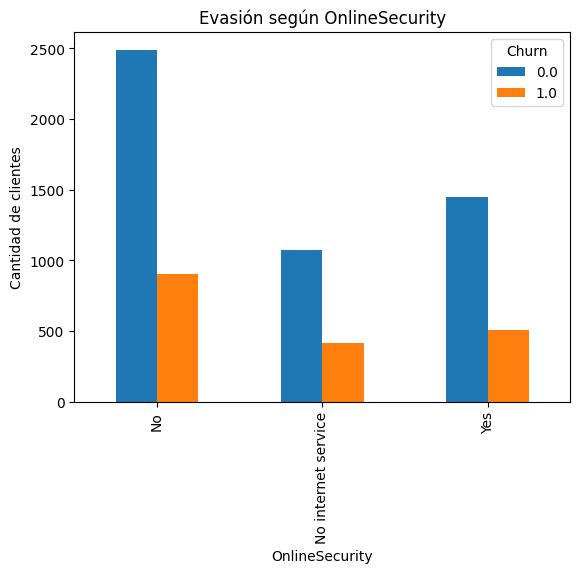

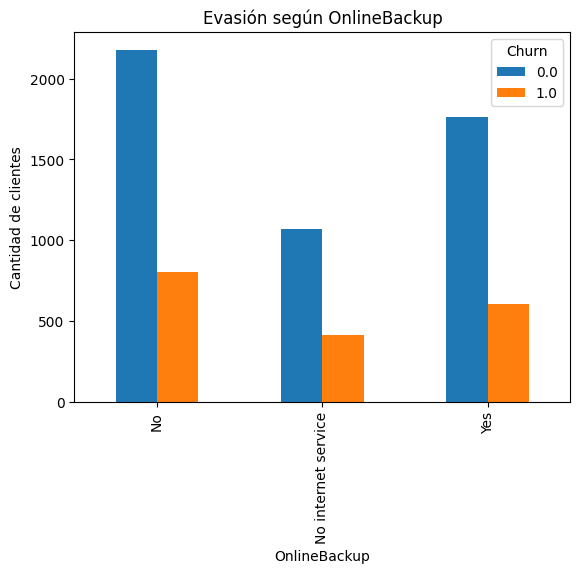

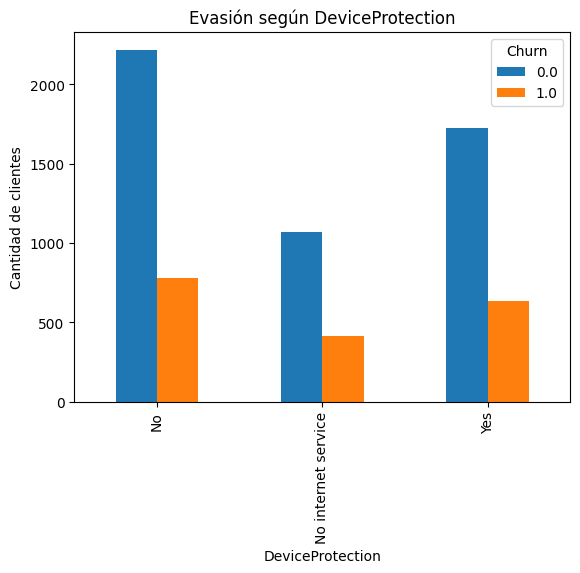

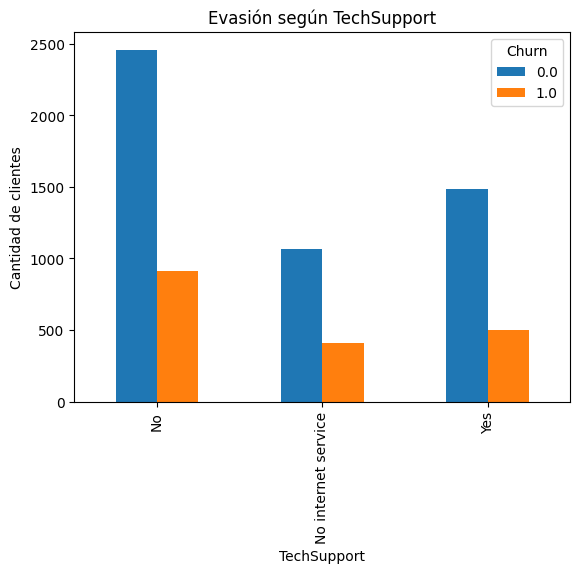

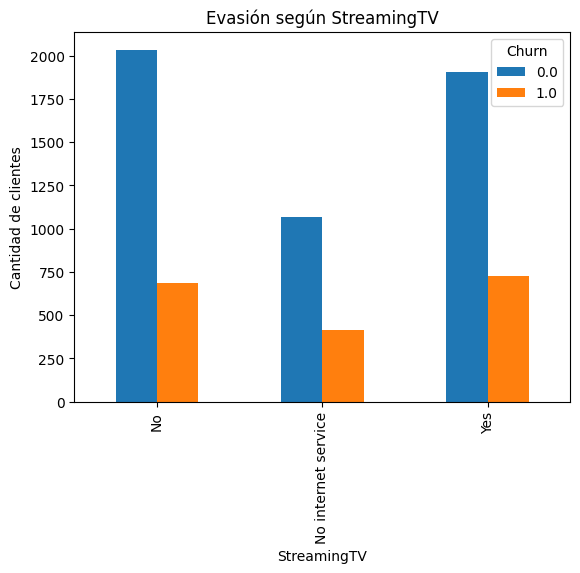

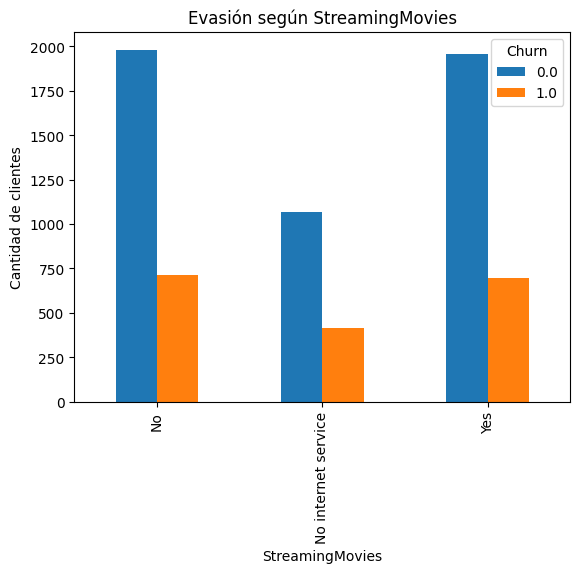

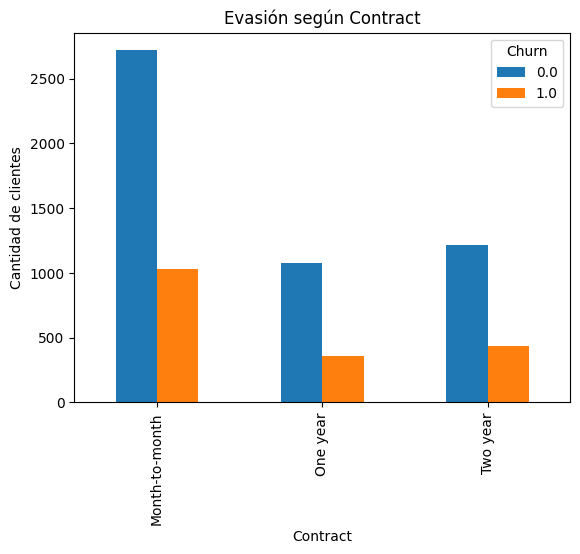

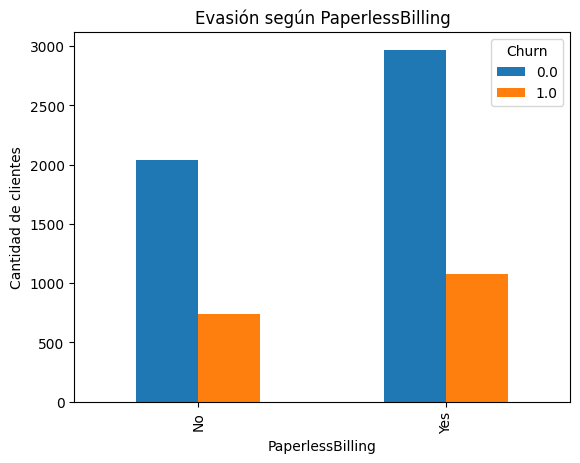

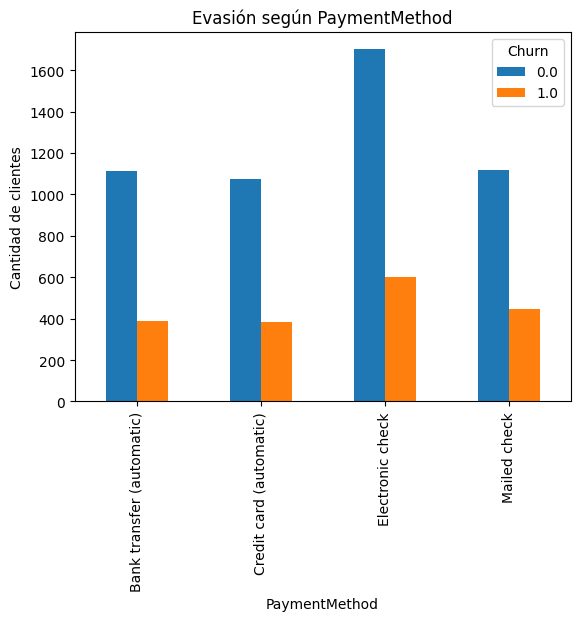

In [94]:
columnas_categoricas = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaperlessBilling',
    'PaymentMethod'
]

for col in columnas_categoricas:
    tabla = pd.crosstab(df[col], df['Churn'])
    tabla.plot(kind='bar')
    plt.title(f'Evasión según {col}')
    plt.ylabel('Cantidad de clientes')
    plt.xlabel(col)
    plt.show()

#Conteo de evasión por variables numéricas

In [95]:
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')

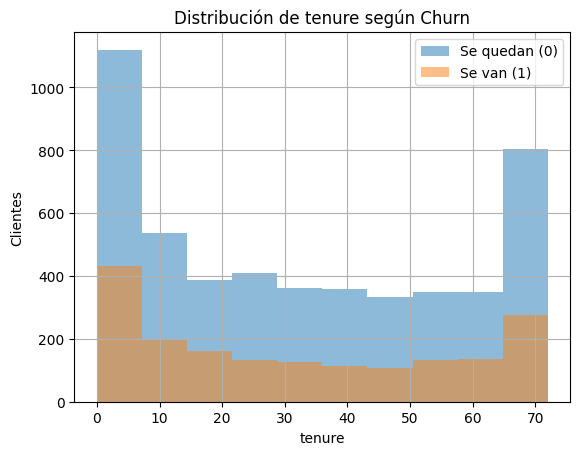

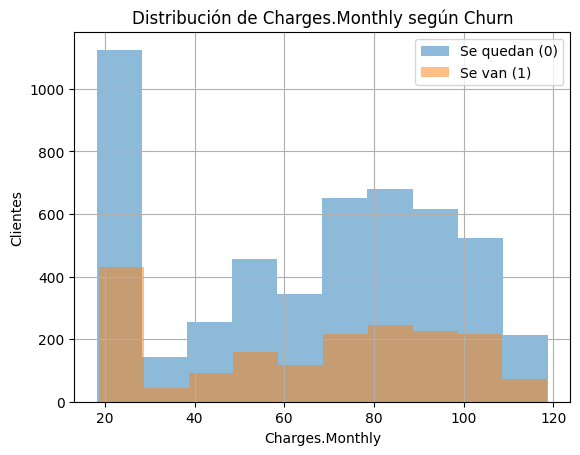

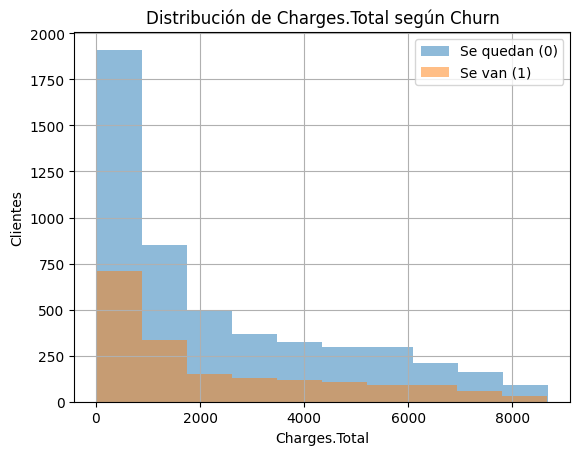

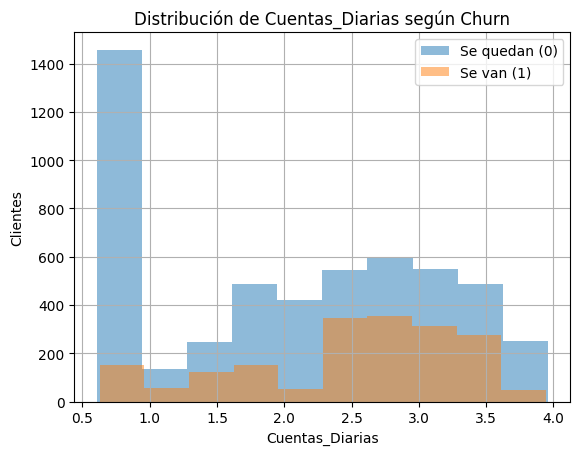

In [96]:
columnas_numericas = [
    'tenure',
    'Charges.Monthly',
    'Charges.Total',
    'Cuentas_Diarias'
]

for col in columnas_numericas:
    plt.figure()
    df[df['Churn'] == 0][col].hist(alpha=0.5)
    df[df['Churn'] == 1][col].hist(alpha=0.5)
    plt.title(f'Distribución de {col} según Churn')
    plt.xlabel(col)
    plt.ylabel('Clientes')
    plt.legend(['Se quedan (0)', 'Se van (1)'])
    plt.show()

#📄Informe final

#Informe de Análisis de Evasión de Clientes - Telecom X

##Introducción

El objetivo de este análisis es comprender los factores que influyen en la evasión de clientes (Churn) en la empresa Telecom X. La evasión de clientes ocurre cuando un usuario decide cancelar los servicios contratados, lo que representa un problema importante para la empresa, ya que afecta sus ingresos y crecimiento.

A través de este análisis de datos, se busca identificar patrones y características de los clientes que tienen mayor probabilidad de cancelar el servicio, utilizando técnicas de análisis exploratorio de datos (EDA).

##Limpieza y Tratamiento de Datos

En esta etapa se realizó la preparación de los datos para garantizar que fueran adecuados para el análisis. Se llevaron a cabo los siguientes pasos:

- Importación de los datos desde la API en formato JSON.

- Conversión de los datos a un DataFrame utilizando Pandas.

- Exploración de la estructura del dataset y revisión de los tipos de datos.

- Identificación de valores faltantes e inconsistencias en algunas variables.

- Eliminación o corrección de valores vacíos.

- Transformación de la variable Churn, convirtiendo los valores "Yes" y "No" en valores binarios (1 y 0).

- Creación de la columna Cuentas_Diarias, calculada a partir de la facturación mensual.

- Conversión de variables numéricas al formato adecuado para el análisis.

- Estos pasos permitieron obtener un conjunto de datos limpio y listo para el análisis exploratorio.

##Análisis Exploratorio de Datos

Se realizaron diferentes análisis para comprender el comportamiento de los clientes y su relación con la evasión.

###Distribución de la evasión de clientes

Se observó que la mayoría de los clientes permanecen en la empresa, mientras que una menor proporción decide cancelar el servicio. Sin embargo, el número de clientes que abandonan el servicio sigue siendo significativo y merece atención.

###Análisis por variables categóricas

- El análisis mostró algunos patrones importantes:

- Los clientes con contratos mensuales (Month-to-month) presentan la mayor tasa de evasión.

- El método de pago Electronic check presenta un mayor número de cancelaciones.

- Los clientes que utilizan Fiber optic muestran mayores niveles de evasión en comparación con otros servicios de internet.

- Los clientes que no cuentan con soporte técnico tienen una mayor probabilidad de cancelar el servicio.

- La variable Partner no muestra una diferencia muy significativa en la evasión de clientes.

###Análisis por variables numéricas

- El análisis de variables numéricas permitió identificar patrones en el comportamiento de los clientes:

- Los clientes que cancelan el servicio suelen tener poco tiempo en la empresa (tenure bajo).

- Existe relación entre algunos rangos de facturación mensual y la evasión.

- Los clientes que abandonan el servicio suelen tener un gasto total menor, lo que indica que permanecieron menos tiempo en la empresa.

##Conclusiones e Insights

- A partir del análisis realizado, se identificaron varios factores asociados a la evasión de clientes:

- Los contratos mensuales presentan mayor riesgo de cancelación.

- La falta de soporte técnico puede influir en la decisión de abandonar el servicio.

- Los clientes nuevos son más propensos a cancelar el servicio.

- Algunos métodos de pago y tipos de servicio presentan mayores niveles de evasión.

Estos hallazgos permiten entender mejor el comportamiento de los clientes y ayudan a identificar oportunidades de mejora en la estrategia de retención.

##Recomendaciones

- Con base en los resultados del análisis, se sugieren las siguientes estrategias para reducir la evasión de clientes:

- Incentivar a los clientes a elegir contratos de mayor duración mediante descuentos o beneficios.

- Mejorar la calidad y disponibilidad del soporte técnico para los clientes.

- Implementar estrategias de fidelización para los clientes nuevos durante sus primeros meses en la empresa.

- Analizar posibles problemas o costos asociados al servicio de fibra óptica.

- Revisar la experiencia de los clientes que utilizan el método de pago electronic check.

Aplicar estas estrategias podría ayudar a mejorar la retención de clientes y reducir la tasa de evasión en la empresa.